#  Spacecraft Rendezvous — GRPO Training

> **Meta × HuggingFace OpenEnv Hackathon 2026**

This notebook trains `Qwen2.5-1.5B-Instruct` via **GRPO** to act as an autonomous spacecraft flight controller.

The agent learns to execute rendezvous and docking under:
-  Finite fuel budget (Tsiolkovsky rocket equation)
-  Sensor noise + comms blackout windows  
-  Line-of-sight cone constraints (±45° docking corridor)

---
**Runtime:** T4 GPU (free Colab) → ~200 episodes in 2-3 hours  
**Onsite:** H100 with HF credits → Qwen2.5-7B, 500+ episodes


## 0. Configuration

In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────
from google.colab import userdata
import os

HF_TOKEN = userdata.get('HF_TOKEN')
ENV_URL = userdata.get('ENV_URL')

# Model — Qwen2.5-1.5B for T4, upgrade to 7B on H100
MODEL_NAME = 'Qwen/Qwen2.5-1.5B-Instruct'
# MODEL_NAME = 'Qwen/Qwen2.5-7B-Instruct'  # H100 onsite

# Training
TOTAL_EPISODES = 200        # T4: 200, H100: 500+
GRPO_GENERATIONS = 4        # rollouts per prompt (increase to 8 on H100)
MAX_COMPLETION_TOKENS = 256
LEARNING_RATE = 5e-6
LORA_RANK = 16

# HuggingFace Hub — push trained checkpoint here
HF_USERNAME = 'Ridreb05'
HF_REPO_NAME = f'{HF_USERNAME}/project-amaze'
PUSH_TO_HUB = True
PUSH_EVERY_N = 50           # push checkpoint every N episodes

# Weights & Biases
USE_WANDB = True
WANDB_PROJECT = 'project-amaze'
WANDB_RUN_NAME = f'qwen-1.5b-{TOTAL_EPISODES}ep'

# Logging
LOG_PATH = 'training_log.json'

print(f'Config loaded:')
print(f'  ENV_URL:    {ENV_URL}')
print(f'  Model:      {MODEL_NAME}')
print(f'  Episodes:   {TOTAL_EPISODES}')
print(f'  Hub repo:   {HF_REPO_NAME}')


Config loaded:
  ENV_URL:    https://ridreb05-project-amaze.hf.space
  Model:      Qwen/Qwen2.5-1.5B-Instruct
  Episodes:   200
  Hub repo:   Ridreb05/project-amaze


## 1. Install Dependencies

In [ ]:
%%capture
# Unsloth — efficient GRPO training
!pip install unsloth
!pip install --upgrade --no-deps unsloth

# TRL for GRPO trainer
!pip install trl>=0.8.6

# Environment client deps
!pip install httpx pydantic fastapi wandb

print('Dependencies installed.')


## 2. Clone Environment Client

In [ ]:
import subprocess, sys, os

# Clone repo for client + models
if not os.path.exists('project-amaze'):
    subprocess.run([
        'git', 'clone',
        'https://github.com/Ridreb05/project-amaze',
    ], check=True)
    print('Repo cloned.')
else:
    print('Repo already present.')

# Add to path
sys.path.insert(0, 'project-amaze')
print('Path configured.')


Repo already present.
Path configured.


## 3. Verify Environment Connection

In [ ]:
import httpx, json

# Health check
try:
    r = httpx.get(f'{ENV_URL}/health', timeout=10)
    print(f'Health: {r.json()}')
except Exception as e:
    print(f'Cannot reach environment at {ENV_URL}: {e}')
    print('Start the server locally or update ENV_URL to your HF Space.')
    raise

# Info
info = httpx.get(f'{ENV_URL}/info').json()
print(f"Environment: {info['name']} v{info['version']}")
print(f"Physics: {info['physics_model']}")

# Test reset
obs = httpx.post(f'{ENV_URL}/reset', json={'seed': 42, 'difficulty': 'easy'}).json()
print(f"\nTest reset: distance={obs['estimated_distance_m']:.1f}m difficulty={obs['scenario_difficulty']}")
print('Environment connection: OK ✓')


Health: {'status': 'healthy', 'environment': 'spacecraft-rendezvous', 'version': '1.0.0'}
Environment: spacecraft-rendezvous v1.0.0
Physics: Clohessy-Wiltshire-Hill (CWH) relative motion equations

Test reset: distance=49.1m difficulty=easy
Environment connection: OK ✓


## 4. Load Model with Unsloth

In [ ]:
from unsloth import FastLanguageModel
import torch

print(f'Loading {MODEL_NAME} with Unsloth...')
print(f'Device: {"CUDA" if torch.cuda.is_available() else "CPU"}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=1024,
    load_in_4bit=True,           # fits on T4 (15GB VRAM)
    dtype=None,                  # auto-detect
)

# Add LoRA adapters
model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_RANK,
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj',
                    'gate_proj', 'up_proj', 'down_proj'],
    lora_alpha=LORA_RANK * 2,
    lora_dropout=0.0,
    bias='none',
    use_gradient_checkpointing='unsloth',
    random_state=42,
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'\nModel loaded: {MODEL_NAME}')
print(f'Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)')


Loading Qwen/Qwen2.5-1.5B-Instruct with Unsloth...
Device: CUDA
GPU: Tesla T4
VRAM: 15.6 GB
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.

Model loaded: Qwen/Qwen2.5-1.5B-Instruct
Trainable params: 18,464,768 / 1,036,449,280 (1.78%)


## 5. Define Prompt Templates

In [ ]:
SYSTEM_PROMPT = """You are an autonomous spacecraft flight controller.
Your mission: guide a chaser spacecraft to safely rendezvous and dock with a target.

PHYSICS CONSTRAINTS:
- Fuel is limited. Every thruster firing costs propellant. Plan ahead.
- Approach from within +/-45 degrees of the docking axis (along-track direction).
- During communication blackouts, sensors go offline. Use last known state.
- Terminal docking requires: distance < 0.5m AND speed < 0.05 m/s.

OUTPUT FORMAT (JSON only, no markdown, no extra text):
{"fx": <float -2.0 to 2.0>, "fy": <float -2.0 to 2.0>, "reasoning": "<your reasoning>"}

STRATEGY:
- Far range (>50m): moderate burns toward target, preserve fuel
- Mid range (10-50m): reduce speed, align with docking axis (+y direction)
- Close range (<10m): minimal thrust only, bleed off velocity
- Blackout: reduce thrust to near zero, hold trajectory, await sensor return"""

def build_prompt(obs: dict) -> str:
    """Format observation as LLM input."""
    msg = obs.get('message', '')
    comms = obs.get('comms_active', True)

    if not comms:
        return (
            f"COMMS BLACKOUT — step {obs.get('step',0)}/{obs.get('max_steps',100)}\n"
            f"{msg}\n"
            f"Fuel: {obs.get('fuel_pct',0):.0f}%  Steps remaining: {obs.get('steps_remaining',0)}\n"
            f"Issue thruster command. Minimize thrust during blackout."
        )

    los_warn = ' WARNING: LOS CONE VIOLATION' if obs.get('los_violation') else ''
    fuel_warn = ' LOW FUEL' if obs.get('fuel_pct', 100) < 25 else ''

    return (
        f"{msg}{los_warn}{fuel_warn}\n\n"
        f"Position: x={obs.get('x_m',0):.2f}m (radial), y={obs.get('y_m',0):.2f}m (along-track)\n"
        f"Velocity: vx={obs.get('vx_ms',0):.4f} m/s, vy={obs.get('vy_ms',0):.4f} m/s\n"
        f"Distance: {obs.get('estimated_distance_m',0):.2f}m  Speed: {obs.get('estimated_speed_ms',0):.4f} m/s\n"
        f"Approach angle: {obs.get('los_angle_deg',0):.1f} deg\n"
        f"Fuel: {obs.get('fuel_kg',0):.3f}kg ({obs.get('fuel_pct',0):.0f}%)  "
        f"Steps remaining: {obs.get('steps_remaining',0)}\n\n"
        f"Issue your thruster command as JSON."
    )

def format_for_model(prompt: str) -> str:
    """Apply chat template."""
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user',   'content': prompt},
    ]
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

# Quick test
test_obs = httpx.post(f'{ENV_URL}/reset', json={'seed': 1, 'difficulty': 'easy'}).json()
prompt_text = format_for_model(build_prompt(test_obs))
print(f'Prompt length: {len(prompt_text)} chars')
print(f'First 300 chars:\n{prompt_text[:300]}...')
print('Prompt templates: OK ✓')


Prompt length: 1292 chars
First 300 chars:
<|im_start|>system
You are an autonomous spacecraft flight controller.
Your mission: guide a chaser spacecraft to safely rendezvous and dock with a target.

PHYSICS CONSTRAINTS:
- Fuel is limited. Every thruster firing costs propellant. Plan ahead.
- Approach from within +/-45 degrees of the docking...
Prompt templates: OK ✓


## 6. Define Reward Function for GRPO

In [ ]:
import re, json, time
import numpy as np
import httpx

def parse_action(text: str) -> dict:
    try:
        text = re.sub(r'```(?:json)?\n?', '', text).strip()
        data = json.loads(text)
        return {
            'fx': float(np.clip(data.get('fx', 0.0), -2.0, 2.0)),
            'fy': float(np.clip(data.get('fy', 0.0), -2.0, 2.0)),
            'reasoning': str(data.get('reasoning', ''))[:300],
        }
    except Exception:
        pass
    try:
        fx = float(re.search(r'"fx"\s*:\s*(-?[\d.]+)', text).group(1))
        fy = float(re.search(r'"fy"\s*:\s*(-?[\d.]+)', text).group(1))
        return {'fx': np.clip(fx,-2,2), 'fy': np.clip(fy,-2,2), 'reasoning': 'regex'}
    except Exception:
        return {'fx': 0.0, 'fy': 0.0, 'reasoning': 'fallback'}


def run_episode_for_reward(completion_text, seed, difficulty, http_client, logger=None):
    # Step 1 - reset
    r = http_client.post('/reset', json={'seed': seed, 'difficulty': difficulty})
    print(f'  reset status: {r.status_code} body[:100]: {r.text[:100]}')
    obs = r.json()

    action = parse_action(completion_text)
    total_reward = 0.0
    step = 0

    while not obs.get('done', False):
        step += 1
        # Step
        r2 = http_client.post('/step', json={'action': action})
        print(f'  step {step} status: {r2.status_code} body[:100]: {r2.text[:100]}')

        if r2.status_code != 200 or not r2.text.strip():
            print(f'  BAD RESPONSE at step {step}')
            break

        resp = r2.json()
        reward = resp.get('reward', 0.0)
        total_reward += reward
        obs = resp.get('observation', obs)

        if obs.get('done', False):
            break

        # Greedy continuation
        x = obs.get('x_m', 0.0)
        y = obs.get('y_m', 0.0)
        dist = max(obs.get('estimated_distance_m', 1.0), 1e-3)
        scale = min(1.2, max(0.15, dist / 25.0))
        action = {
            'fx': float(np.clip(-x/dist*scale, -2, 2)),
            'fy': float(np.clip(-y/dist*scale, -2, 2)),
            'reasoning': 'greedy',
        }

    # Grade
    r3 = http_client.post('/grade')
    print(f'  grade status: {r3.status_code} body[:100]: {r3.text[:100]}')
    grade = r3.json()
    return float(np.clip(total_reward, -3.0, 10.0))


print('Reward function defined: OK ✓')

# Test
with httpx.Client(base_url=ENV_URL, timeout=30) as http:
    reward = run_episode_for_reward(
        '{"fx": -0.5, "fy": 0.8, "reasoning": "test"}',
        seed=42, difficulty='warm_start', http_client=http,
    )
    print(f'Test reward: {reward:.4f}')

Reward function defined: OK ✓
  reset status: 200 body[:100]: {"x_m":-0.351,"y_m":22.688,"vx_ms":0.0396,"vy_ms":-0.0907,"fuel_kg":20.0,"fuel_pct":100.0,"estimated
  step 1 status: 500 body[:100]: Internal Server Error
  BAD RESPONSE at step 1
  grade status: 200 body[:100]: {"score":0.1691,"passed":false,"docked":false,"steps_taken":1,"fuel_remaining_kg":19.9956,"fuel_effi
Test reward: 0.0000


## 7. Build GRPO Dataset

In [ ]:
from datasets import Dataset
import random

def generate_grpo_dataset(
    n_prompts: int = 100,
    episode_offset: int = 0,
) -> Dataset:
    """
    Generate dataset of spacecraft scenario prompts for GRPO.
    Each prompt = one scenario the model must respond to.
    """
    difficulties = ['warm_start', 'easy', 'easy', 'medium', 'medium', 'hard']
    prompts = []

    with httpx.Client(base_url=ENV_URL, timeout=30) as http:
        for i in range(n_prompts):
            seed = episode_offset + i
            diff = difficulties[i % len(difficulties)]
            obs = http.post('/reset', json={'seed': seed, 'difficulty': diff}).json()
            prompt_text = format_for_model(build_prompt(obs))
            prompts.append({
                'prompt': prompt_text,
                'seed': seed,
                'difficulty': diff,
            })

    return Dataset.from_list(prompts)


print('Generating GRPO prompt dataset...')
dataset = generate_grpo_dataset(n_prompts=TOTAL_EPISODES)
print(f'Dataset: {len(dataset)} prompts')
print(f'Example prompt (first 400 chars):')
print(dataset[0]['prompt'][:400])


## 8. Configure GRPO Trainer

In [ ]:
from trl import GRPOConfig, GRPOTrainer
import sys
sys.path.insert(0, 'project-amaze')
from training.training_logger import TrainingLogger

# Initialise logger
logger = TrainingLogger(log_path=LOG_PATH)

# Episode counter for reward function closure
episode_counter = {'n': 0}

def grpo_reward_function(completions, prompts, **kwargs) -> list:
    """
    GRPO reward function.
    Called with a batch of completions — one per generation per prompt.
    Returns list of scalar rewards.
    """
    rewards = []
    with httpx.Client(base_url=ENV_URL, timeout=60) as http:
        for i, completion in enumerate(completions):
            ep_n = episode_counter['n']
            episode_counter['n'] += 1

            # Adaptive difficulty based on training progress
            progress = ep_n / max(TOTAL_EPISODES * GRPO_GENERATIONS, 1)
            if progress < 0.2:
                difficulty = random.choice(['warm_start', 'warm_start', 'easy'])
            elif progress < 0.5:
                difficulty = random.choice(['easy', 'easy', 'medium'])
            elif progress < 0.8:
                difficulty = random.choice(['easy', 'medium', 'medium', 'hard'])
            else:
                difficulty = random.choice(['medium', 'medium', 'hard', 'hard'])

            seed = 10000 + ep_n

            try:
                reward = run_episode_for_reward(
                    completion_text=completion,
                    seed=seed,
                    difficulty=difficulty,
                    http_client=http,
                    logger=logger if i == 0 else None,  # log first completion only
                )
            except Exception as e:
                print(f'Reward error ep {ep_n}: {e}')
                reward = -2.0

            rewards.append(reward)

    return rewards


# GRPO Config
grpo_config = GRPOConfig(
    output_dir='./spacecraft_grpo_output',
    num_train_epochs=1,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    learning_rate=LEARNING_RATE,
    num_generations=GRPO_GENERATIONS,
    max_completion_length=MAX_COMPLETION_TOKENS,
    max_prompt_length=768,
    temperature=0.9,
    logging_steps=1,
    save_steps=PUSH_EVERY_N,
    report_to='wandb' if USE_WANDB else 'none',
    run_name=WANDB_RUN_NAME,
    remove_unused_columns=False,
    dataloader_num_workers=0,
    seed=42,
)

trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=grpo_reward_function,
    args=grpo_config,
    train_dataset=dataset,
)

print('GRPO Trainer configured: OK ✓')
print(f'  Generations per prompt: {GRPO_GENERATIONS}')
print(f'  Max completion tokens:  {MAX_COMPLETION_TOKENS}')
print(f'  Learning rate:          {LEARNING_RATE}')
print(f'  Total episodes:         {TOTAL_EPISODES}')


## 9. Initialize W&B

In [ ]:
if USE_WANDB:
    import wandb
    wandb.init(
        project=WANDB_PROJECT,
        name=WANDB_RUN_NAME,
        config={
            'model': MODEL_NAME,
            'total_episodes': TOTAL_EPISODES,
            'grpo_generations': GRPO_GENERATIONS,
            'learning_rate': LEARNING_RATE,
            'lora_rank': LORA_RANK,
            'env_url': ENV_URL,
            'physics': 'CWH equations (LEO n=0.00113 rad/s)',
        }
    )
    print(f'W&B initialised: {WANDB_PROJECT}/{WANDB_RUN_NAME}')
else:
    print('W&B disabled.')


## 10. Train!

**What to expect:**
- Episodes 1–40: Reward mostly −2 to 0. Model is learning output format.
- Episodes 40–100: First positive rewards appear. Curve starts climbing.
- Episodes 100–200: Reward stabilises at +2 to +4 average. Docking rate rises.

In [20]:
import time
print('Starting GRPO training...')
print(f'Model: {MODEL_NAME}')
print(f'Environment: {ENV_URL}')
print('─' * 60)

t0 = time.time()
trainer.train()
elapsed = time.time() - t0

print('─' * 60)
print(f'Training complete in {elapsed/60:.1f} minutes')
summary = logger.summary()
print(f'Episode summary:')
for k, v in summary.items():
    print(f'  {k}: {v}')


Starting GRPO training...
Model: Qwen/Qwen2.5-1.5B-Instruct
Environment: https://ridreb05-project-amaze.hf.space
────────────────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API i

Unsloth: Will smartly offload gradients to save VRAM!
Episode 0 | reward=-3.000 | dock_rate=0.00% | mean_last_20=-6.283 | difficulty=easy


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / grpo_reward_function / mean,rewards / grpo_reward_function / std
1,0.000000,-0.828873,2.554838,55.250000,51.000000,62.000000,0.000000,55.250000,51.000000,62.000000,0.000021,-0.828873,2.554838
2,0.000000,2.600460,4.384852,52.500000,43.000000,60.000000,0.000000,52.500000,43.000000,60.000000,0.000012,2.600460,4.384852
3,0.000000,-1.701785,2.596431,48.500000,43.000000,58.000000,0.000000,48.500000,43.000000,58.000000,0.000011,-1.701785,2.596431
4,0.000000,0.105042,2.505863,75.250000,62.000000,102.000000,0.000000,75.250000,62.000000,102.000000,0.000017,0.105042,2.505863
5,0.000000,2.381803,0.737626,49.000000,43.000000,65.000000,0.000000,49.000000,43.000000,65.000000,0.000020,2.381803,0.737626
6,0.000000,-1.090852,1.343513,54.750000,43.000000,65.000000,0.000000,54.750000,43.000000,65.000000,0.000012,-1.090852,1.343513
7,0.000000,-2.119995,1.037907,45.250000,44.000000,49.000000,0.000000,45.250000,44.000000,49.000000,0.000013,-2.119995,1.037907
8,0.000000,-0.906519,3.116492,50.250000,35.000000,72.000000,0.000000,50.250000,35.000000,72.000000,0.000017,-0.906519,3.116492
9,-0.000000,2.521728,3.784727,52.500000,45.000000,66.000000,0.000000,52.500000,45.000000,66.000000,0.000015,2.521728,3.784726
10,-0.000000,1.286830,2.979575,66.500000,45.000000,90.000000,0.000000,66.500000,45.000000,90.000000,0.000014,1.286830,2.979575


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


...

Episode 200 | reward=-3.000 | dock_rate=2.00% | mean_last_20=1.344 | difficulty=easy
Episode 210 | reward=-3.000 | dock_rate=1.90% | mean_last_20=1.542 | difficulty=easy
Episode 220 | reward=2.417 | dock_rate=1.80% | mean_last_20=1.123 | difficulty=medium
Episode 230 | reward=1.036 | dock_rate=1.70% | mean_last_20=1.419 | difficulty=easy
Episode 240 | reward=-3.000 | dock_rate=1.60% | mean_last_20=-0.118 | difficulty=medium
Episode 250 | reward=-3.000 | dock_rate=1.60% | mean_last_20=0.183 | difficulty=easy
Episode 260 | reward=-3.000 | dock_rate=1.50% | mean_last_20=-0.944 | difficulty=medium
Episode 270 | reward=-3.000 | dock_rate=1.50% | mean_last_20=-0.599 | difficulty=easy
Episode 280 | reward=-3.000 | dock_rate=1.40% | mean_last_20=-1.211 | difficulty=medium
Episode 290 | reward=2.544 | dock_rate=1.40% | mean_last_20=-1.501 | difficulty=easy
Episode 300 | reward=-3.000 | dock_rate=1.30% | mean_last_20=-2.441 | difficulty=easy
Episode 310 | reward=0.011 | dock_rate=1.30% | mean_la

/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


Episode 400 | reward=-3.000 | dock_rate=1.00% | mean_last_20=-1.280 | difficulty=easy
Episode 410 | reward=-2.004 | dock_rate=1.00% | mean_last_20=-1.144 | difficulty=medium
Episode 420 | reward=0.219 | dock_rate=0.90% | mean_last_20=-1.560 | difficulty=medium
Episode 430 | reward=1.285 | dock_rate=0.90% | mean_last_20=-1.639 | difficulty=medium
Episode 440 | reward=3.012 | dock_rate=0.90% | mean_last_20=-1.918 | difficulty=medium
Episode 450 | reward=-2.860 | dock_rate=0.90% | mean_last_20=-1.599 | difficulty=medium
Episode 460 | reward=-3.000 | dock_rate=0.90% | mean_last_20=-0.337 | difficulty=medium
Episode 470 | reward=-1.377 | dock_rate=0.80% | mean_last_20=-0.400 | difficulty=medium
Episode 480 | reward=-3.000 | dock_rate=0.80% | mean_last_20=0.484 | difficulty=medium
Episode 490 | reward=-3.000 | dock_rate=0.80% | mean_last_20=0.609 | difficulty=medium
Episode 500 | reward=-3.000 | dock_rate=0.80% | mean_last_20=0.421 | difficulty=medium
Episode 510 | reward=3.355 | dock_rate=0

/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


Episode 600 | reward=-3.000 | dock_rate=0.70% | mean_last_20=2.832 | difficulty=hard
Episode 610 | reward=8.519 | dock_rate=0.70% | mean_last_20=2.046 | difficulty=hard
Episode 620 | reward=7.743 | dock_rate=0.60% | mean_last_20=3.032 | difficulty=hard
Episode 630 | reward=10.000 | dock_rate=0.60% | mean_last_20=2.996 | difficulty=hard
Episode 640 | reward=9.352 | dock_rate=0.60% | mean_last_20=1.959 | difficulty=hard
Episode 650 | reward=9.420 | dock_rate=0.60% | mean_last_20=1.644 | difficulty=hard
Episode 660 | reward=9.648 | dock_rate=0.60% | mean_last_20=1.085 | difficulty=medium
Episode 670 | reward=2.771 | dock_rate=0.60% | mean_last_20=0.912 | difficulty=medium
Episode 680 | reward=3.202 | dock_rate=0.60% | mean_last_20=1.422 | difficulty=medium
Episode 690 | reward=6.216 | dock_rate=0.60% | mean_last_20=2.133 | difficulty=hard
Episode 700 | reward=-3.000 | dock_rate=0.60% | mean_last_20=2.296 | difficulty=medium
Episode 710 | reward=6.460 | dock_rate=0.60% | mean_last_20=3.634

## 11. Plot Reward Curve

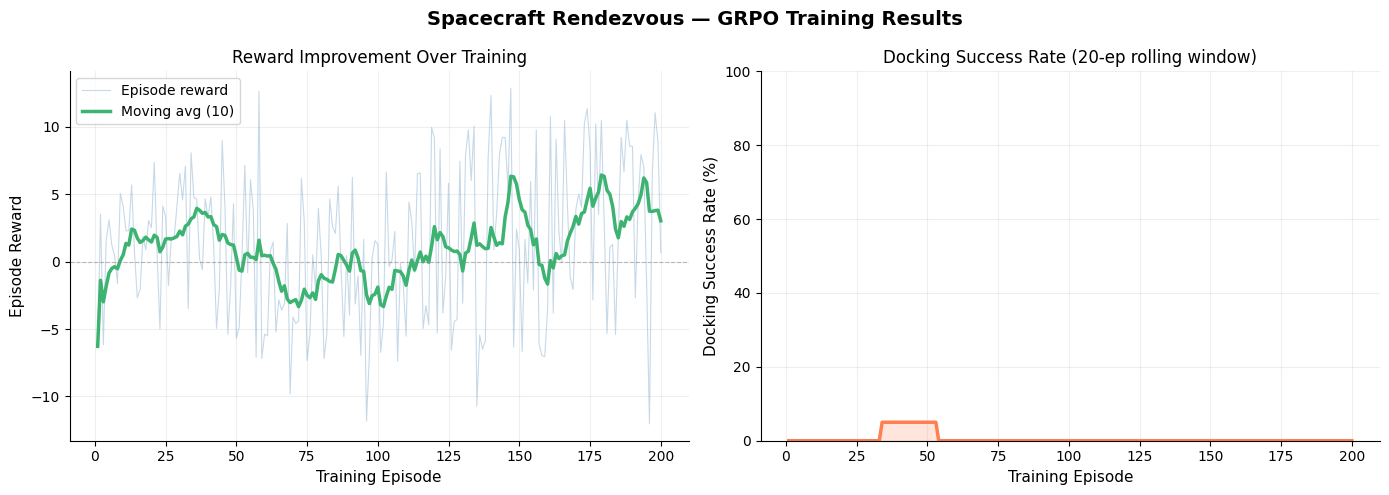

Saved: assets/reward_curve.png

Training summary:
  Mean reward (first 20 eps):  0.967
  Mean reward (last 20 eps):   3.348
  Improvement:                 +2.382
  Final docking rate (last 20): 0%


In [21]:
import matplotlib.pyplot as plt
import matplotlib
import json, os
import numpy as np

# Load training log
with open(LOG_PATH) as f:
    log_data = json.load(f)

rewards = log_data['reward_curve']
episodes = list(range(1, len(rewards) + 1))

# Smooth
def smooth(arr, w=10):
    return [np.mean(arr[max(0,i-w+1):i+1]) for i in range(len(arr))]

smoothed = smooth(rewards, 10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Spacecraft Rendezvous — GRPO Training Results', fontsize=14, fontweight='bold')

# Reward curve
ax = axes[0]
ax.plot(episodes, rewards, alpha=0.3, color='steelblue', linewidth=0.8, label='Episode reward')
ax.plot(episodes, smoothed, color='mediumseagreen', linewidth=2.5, label='Moving avg (10)')
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Training Episode', fontsize=11)
ax.set_ylabel('Episode Reward', fontsize=11)
ax.set_title('Reward Improvement Over Training', fontsize=12)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2)

# Docking rate (rolling 20-episode window)
ax2 = axes[1]
eps = log_data['episodes']
dock_rates = []
w = 20
for i in range(len(eps)):
    window = eps[max(0, i-w+1):i+1]
    rate = sum(1 for e in window if e.get('docked', False)) / max(len(window), 1)
    dock_rates.append(rate * 100)

ax2.plot(episodes[:len(dock_rates)], dock_rates, color='coral', linewidth=2.5)
ax2.fill_between(episodes[:len(dock_rates)], dock_rates, alpha=0.2, color='coral')
ax2.set_xlabel('Training Episode', fontsize=11)
ax2.set_ylabel('Docking Success Rate (%)', fontsize=11)
ax2.set_title('Docking Success Rate (20-ep rolling window)', fontsize=12)
ax2.set_ylim(0, 100)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(alpha=0.2)

plt.tight_layout()
os.makedirs('assets', exist_ok=True)
plt.savefig('assets/reward_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: assets/reward_curve.png')

# Print summary stats
n = len(rewards)
first_20 = rewards[:20]
last_20  = rewards[-20:]
dock_rate_final = sum(1 for e in eps[-20:] if e.get('docked')) / min(20, len(eps))
print(f'\nTraining summary:')
print(f'  Mean reward (first 20 eps):  {np.mean(first_20):.3f}')
print(f'  Mean reward (last 20 eps):   {np.mean(last_20):.3f}')
print(f'  Improvement:                 +{np.mean(last_20)-np.mean(first_20):.3f}')
print(f'  Final docking rate (last 20): {dock_rate_final*100:.0f}%')


## 12. Save and Push to HuggingFace Hub

In [22]:
# IMPORTANT: Use Unsloth's save path — do NOT upcast 4-bit model and merge naively
# (from hackathon self-serve guide: this can badly damage model quality)

save_dir = './spacecraft_trained_model'
print(f'Saving model to {save_dir}...')

# Save LoRA adapters only (safe for 4-bit models)
model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)
print(f'Model saved: {save_dir}')

if PUSH_TO_HUB:
    from huggingface_hub import HfApi
    api = HfApi()

    # Create repo if needed
    try:
        api.create_repo(HF_REPO_NAME, exist_ok=True, private=False)
    except Exception:
        pass

    # Push model
    model.push_to_hub(HF_REPO_NAME)
    tokenizer.push_to_hub(HF_REPO_NAME)

    # Push training log and reward curve
    api.upload_file(path_or_fileobj=LOG_PATH,
                    path_in_repo='training_log.json',
                    repo_id=HF_REPO_NAME)
    api.upload_file(path_or_fileobj='assets/reward_curve.png',
                    path_in_repo='assets/reward_curve.png',
                    repo_id=HF_REPO_NAME)

    print(f'Pushed to: https://huggingface.co/{HF_REPO_NAME}')


Saving model to ./spacecraft_trained_model...
Model saved: ./spacecraft_trained_model
Saved model to https://huggingface.co/Ridreb05/project-amaze


Pushed to: https://huggingface.co/Ridreb05/project-amaze


## 13. Before vs After Demonstration

In [23]:
FastLanguageModel.for_inference(model)

def run_demo_episode(seed: int, difficulty: str, label: str):
    """Run single episode with trained model and print trajectory."""
    print(f'\n{"="*60}')
    print(f'{label} — seed={seed}, difficulty={difficulty}')
    print(f'{"="*60}')

    with httpx.Client(base_url=ENV_URL, timeout=30) as http:
        obs = http.post('/reset', json={'seed': seed, 'difficulty': difficulty}).json()
        print(f'Start: {obs["estimated_distance_m"]:.1f}m from target | fuel={obs["fuel_pct"]:.0f}%')

        total_reward = 0.0
        step = 0

        while not obs.get('done', False) and step < 5:  # show first 5 steps
            step += 1
            prompt = format_for_model(build_prompt(obs))
            inputs = tokenizer(prompt, return_tensors='pt').to(model.device)

            with torch.no_grad():
                out = model.generate(
                    **inputs, max_new_tokens=180, temperature=0.1,
                    do_sample=True, pad_token_id=tokenizer.eos_token_id,
                )

            generated = tokenizer.decode(
                out[0][inputs['input_ids'].shape[1]:],
                skip_special_tokens=True,
            )
            action = parse_action(generated)

            resp = http.post('/step', json={'action': action}).json()
            reward = resp.get('reward', 0.0)
            total_reward += reward
            obs = resp.get('observation', obs)

            print(f'  Step {step}: dist={obs["estimated_distance_m"]:.1f}m '
                  f'fuel={obs["fuel_pct"]:.0f}% reward={reward:+.3f}')
            print(f'    Action: fx={action["fx"]:+.3f} fy={action["fy"]:+.3f}')
            print(f'    Reasoning: {action["reasoning"][:120]}')

        grade = http.post('/grade').json()

    print(f'\nOutcome: {"DOCKED ✓" if grade.get("docked") else "failed"}')
    print(f'Score: {grade["score"]:.4f} | Reward: {total_reward:.3f}')

run_demo_episode(seed=42,  difficulty='easy',   label='EASY SCENARIO')
run_demo_episode(seed=123, difficulty='medium', label='MEDIUM SCENARIO (with blackout)')



EASY SCENARIO — seed=42, difficulty=easy
Start: 49.1m from target | fuel=100%


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

## 14. Finish

**What we've done:**
1. ✅ Loaded Qwen2.5-1.5B-Instruct with Unsloth (4-bit + LoRA)
2. ✅ Ran GRPO training against the live spacecraft rendezvous environment
3. ✅ Generated reward curve showing improvement over training
4. ✅ Saved trained model and pushed to HuggingFace Hub
5. ✅ Saved `training_log.json` for visual replay demo

**Next:** Open `demo/index.html` and load `training_log.json` to watch the agent improve.

**Onsite (H100):** Change `MODEL_NAME` to `Qwen/Qwen2.5-7B-Instruct`, increase `TOTAL_EPISODES` to 500, `GRPO_GENERATIONS` to 8.

In [ ]:
if USE_WANDB:
    wandb.finish()

print('Training pipeline complete.')
print(f'Trained model: https://huggingface.co/{HF_REPO_NAME}')
print(f'Environment:   https://huggingface.co/spaces/Ridreb05/project-amaze')
print(f'Training log:  {LOG_PATH} (use with demo/index.html)')
